In [1]:
from ccdproc import ImageFileCollection
from astropy.table import unique
from astropy.coordinates import SkyCoord
from sklearn.neighbors import NearestNeighbors
from astroquery.vizier import Vizier
import astropy.units as u
import numpy as np
from matplotlib import pyplot as plt

In [2]:
# dataset='./20171220/'
dataset = './2021-10-29/' # Goodman data

catalog='I/355/gaiadr3'
cat_magnitude='Gmag', 
cat_constraints={'Gmag': '< 20.5','IPDfow': '< 1','sepsi': '< 2'}

ifc = ImageFileCollection(dataset, ext=0,
         keywords=['obstype','ut','ccdsum','airmass','exptime','object'], #,'filter1','filter2'],
         glob_exclude="*master*.fits, bpm*.fits", glob_include="*.fits")

In [4]:
Vizier.ROW_LIMIT = -1
query = Vizier.query_region(SkyCoord(ra=10.214528*u.deg, dec=-73.376458*u.deg, frame='icrs'),
                            width=f"{8:.1f} arcmin", 
                            height=f"{8:.1f} arcmin", 
                            catalog=catalog, column_filters=cat_constraints)


In [5]:
cat=query[0]
cat.sort(cat_magnitude)
ncat=len(cat)
ncat

3780

In [19]:
obj_ifc = ifc.filter(obstype='OBJECT', regex_match=True)
hdr1 = next(obj_ifc.headers())
FoV = np.array([hdr1['NAXIS1']*hdr1['CD1_1'], hdr1['NAXIS2']*hdr1['CD2_2']])*60

for keyw in ['ra','dec','crval1','crval2']: 
    if keyw not in obj_ifc.keywords: obj_ifc.keywords = obj_ifc.keywords+[keyw]
query_tab = unique(obj_ifc.summary, keys=['ra','dec'], keep='last')

query_tab['_RAJ2000'] = query_tab['crval1']*u.degree
query_tab['_DEJ2000'] = query_tab['crval2']*u.degree

query_tab.sort('exptime')
query_tab.reverse()
query_tab

file,obstype,ut,ccdsum,airmass,exptime,object,ra,dec,crval1,crval2,_RAJ2000,_DEJ2000
,,,,,,,,,,,deg,deg
str39,str6,str12,str3,float64,float64,str7,str12,str13,float64,float64,float64,float64
./2021-10-29/0189_SO2021B-018_1029.fits,OBJECT,00:46:21.453,1 1,1.45,600.0,NGC220,00:40:50.657,-73:22:29.066,10.20954534118322,-73.37682061362834,10.20954534118322,-73.37682061362834
./2021-10-29/0190_SO2021B-018_1029.fits,OBJECT,00:56:37.003,1 1,1.43,600.0,NGC220,00:40:50.676,-73:22:29.282,10.209765702893122,-73.37657013882232,10.209765702893122,-73.37657013882232
./2021-10-29/0260_SO2021B-018_1029.fits,OBJECT,05:03:22.903,1 1,1.42,600.0,K67,01:15:41.765,-73:19:39.999,18.924020833333334,-73.3277775,18.924020833333334,-73.3277775
./2021-10-29/0258_SO2021B-018_1029.fits,OBJECT,04:42:49.703,1 1,1.4,600.0,K67,01:15:41.787,-73:19:40.088,18.9241125,-73.32780222222222,18.9241125,-73.32780222222222
./2021-10-29/0259_SO2021B-018_1029.fits,OBJECT,04:53:05.703,1 1,1.41,600.0,K67,01:15:41.747,-73:19:40.192,18.92394583333333,-73.32783111111111,18.92394583333333,-73.32783111111111
./2021-10-29/0293_SO2021B-018_1029.fits,OBJECT,07:01:16.853,1 1,1.58,600.0,ASS64,01:24:29.974,-73:09:21.114,21.124891666666663,-73.155865,21.124891666666663,-73.155865
./2021-10-29/0291_SO2021B-018_1029.fits,OBJECT,06:40:43.103,1 1,1.54,600.0,ASS64,01:24:29.953,-73:09:21.202,21.124804166666664,-73.15588944444445,21.124804166666664,-73.15588944444445
./2021-10-29/0292_SO2021B-018_1029.fits,OBJECT,06:51:01.353,1 1,1.56,600.0,ASS64,01:24:29.992,-73:09:21.193,21.124966666666666,-73.15588694444445,21.124966666666666,-73.15588694444445


In [20]:
coords = SkyCoord(ra=query_tab['_RAJ2000'], dec=query_tab['_DEJ2000'], frame='icrs')
i = 0
while i < len(coords):
    obj = coords[i]
    dist = obj.separation(coords)
    nearby_sources = (dist > 0) & (dist < 1*u.arcmin)
    query_tab.remove_rows(np.where(nearby_sources))
    coords = coords[~nearby_sources]
    i+=1

In [24]:
query_tab

file,obstype,ut,ccdsum,airmass,exptime,object,ra,dec,crval1,crval2,_RAJ2000,_DEJ2000
,,,,,,,,,,,deg,deg
str39,str6,str12,str3,float64,float64,str7,str12,str13,float64,float64,float64,float64
./2021-10-29/0189_SO2021B-018_1029.fits,OBJECT,00:46:21.453,1 1,1.45,600.0,NGC220,00:40:50.657,-73:22:29.066,10.20954534118322,-73.37682061362834,10.20954534118322,-73.37682061362834
./2021-10-29/0260_SO2021B-018_1029.fits,OBJECT,05:03:22.903,1 1,1.42,600.0,K67,01:15:41.765,-73:19:39.999,18.924020833333334,-73.3277775,18.924020833333334,-73.3277775
./2021-10-29/0293_SO2021B-018_1029.fits,OBJECT,07:01:16.853,1 1,1.58,600.0,ASS64,01:24:29.974,-73:09:21.114,21.124891666666663,-73.155865,21.124891666666663,-73.155865
./2021-10-29/0318_SO2021B-018_1029.fits,OBJECT,08:16:58.203,1 1,1.21,400.0,LW261,05:39:10.406,-64:07:58.890,84.79335833333333,-64.13302499999999,84.79335833333333,-64.13302499999999
./2021-10-29/0211_SO2021B-018_1029.fits,OBJECT,02:37:02.653,1 1,1.37,200.0,NC02,01:10:57.788,-72:42:53.077,17.740783333333333,-72.71474361111112,17.740783333333333,-72.71474361111112
./2021-10-29/0175_SO2021B-018_1029.fits,OBJECT,00:22:48.403,1 1,1.42,30.0,NGC121,00:26:48.412,-71:32:04.070,6.735891081466474,-71.55262792442987,6.735891081466474,-71.55262792442987
./2021-10-29/0178_SO2021B-018_1029.fits,OBJECT,00:25:55.903,1 1,1.42,30.0,NGC121,00:26:48.364,-71:32:03.699,6.701516666666667,-71.53436083333334,6.701516666666667,-71.53436083333334
./2021-10-29/0295_SO2021B-018_1029.fits,OBJECT,07:14:51.703,1 1,1.25,30.0,NGC2254,06:30:11.101,-64:19:29.151,97.54625416666667,-64.32476416666667,97.54625416666667,-64.32476416666667


In [46]:
vizier = Vizier(catalog=catalog, column_filters=cat_constraints,
                columns=['RA_ICRS','DE_ICRS','Gmag'])
vizier.ROW_LIMIT = -1

query = vizier.query_region(query_tab,
    width=f"{FoV[0]+1:.1f} arcmin", height=f"{FoV[1]+1:.1f} arcmin")


In [ ]:
obj_ifc = ifc.filter(obstype='OBJECT', regex_match=True)


TableList with 1 tables:
	'0:I/355/gaiadr3' with 4 column(s) and 5895 row(s) 

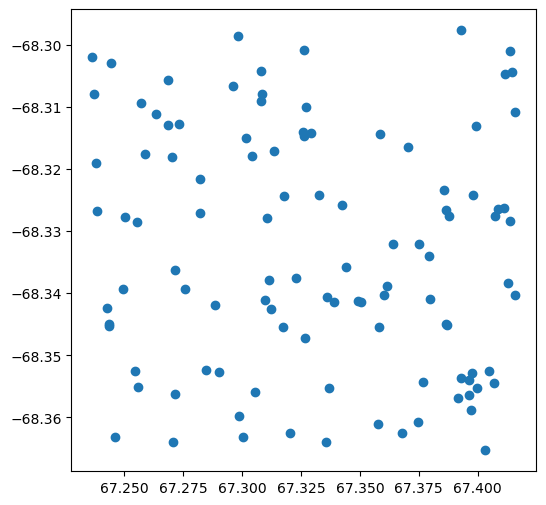

In [10]:
fig,ax = plt.subplots(1,1,figsize=(6,6))

fld = (query[0]['_q'] == 1)
ax.scatter(query[0]['RA_ICRS'][fld], query[0]['DE_ICRS'][fld])

In [7]:
print(FoV)

[3.072 3.084]
